In [1]:
import sys, os
from utils import * 


In [2]:
import joblib

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("IEEE_data.pkl")
y_test = y_test.values.ravel()

MODEL_NAME = "K_Means"
DE_LONG_RESULTS = "IEEE_CIS_all_results.pkl"
METRICS = "IEEE_CIS_metrics.pkl"


In [3]:
# ==================================================
# ==================================================
# ==================================================
# ==================================================
# ==================================================
# =================== 3. K-Means ===================
# ==================================================
# ==================================================
# ==================================================
# ==================================================
# ==================================================

In [4]:
# ===================== 3. K-Means =====================
KM_train_scores, KM_test_scores, KM_model = run_kmeans(X_train, X_test)


In [16]:
# ===================== Store metrics =====================
KM_metrics = store_anomaly_metrics(y_true=y_test, scores=-KM_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)
display(KM_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,K_Means,train_transaction22,0.080752,0.073-0.088,0.115413,0.105-0.125,0.09502,0.086-0.103,0.591713,0.583-0.601,0.050456,0.048-0.053,"[[108545, 5430], [3656, 477]]",2.204287


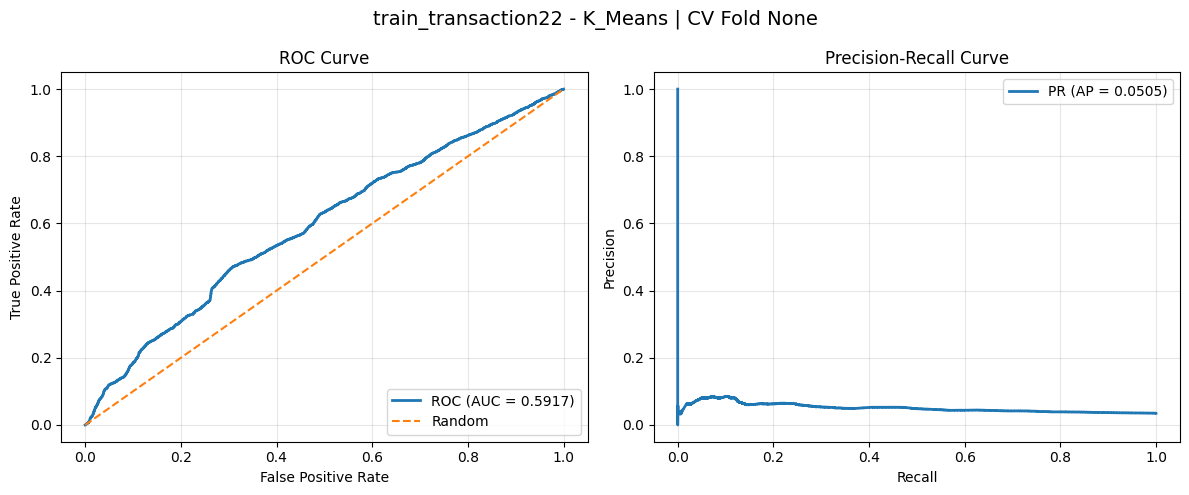

In [22]:
# ===================== Plot results =====================
plot_anomaly_roc_pr(y_true=y_test, scores=-KM_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)


In [ ]:
# ===================== Fit on CV folds =====================
KM_results = fit_cross_validate(X_train, y_train, X_test, y_test, run_kmeans, DATASET_NAME, MODEL_NAME, CV_FOLDS, RANDOM_STATE)


In [18]:
# ===================== Store CV metrics =====================

KM_cv_metrics = pd.concat([r["test_metrics"] for r in KM_results], ignore_index=True)
display(KM_metrics)



,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,K_Means,train_transaction22,0.080752,0.073-0.088,0.115413,0.105-0.125,0.09502,0.086-0.103,0.591713,0.583-0.601,0.050456,0.048-0.053,"[[108545, 5430], [3656, 477]]",2.204287


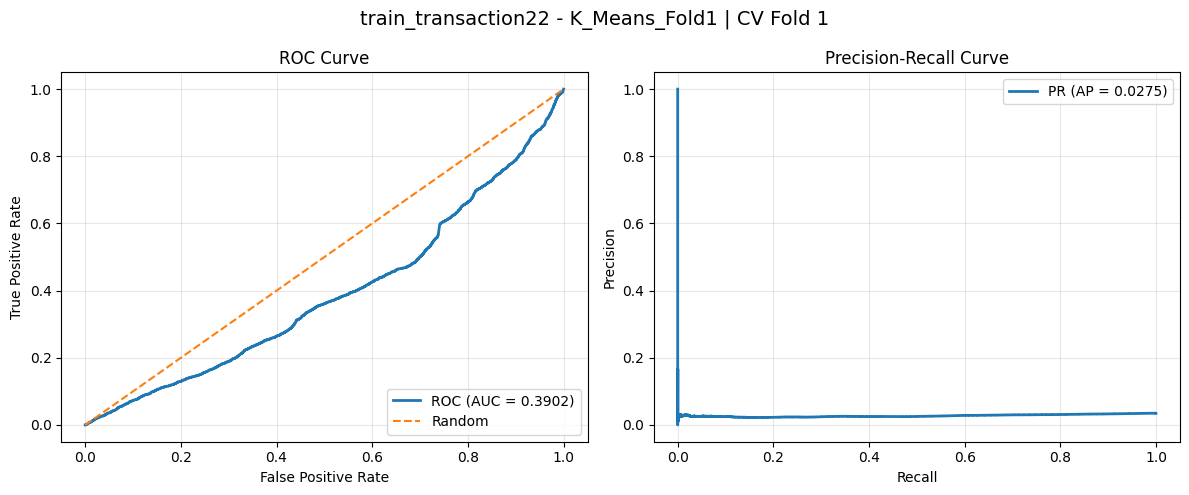

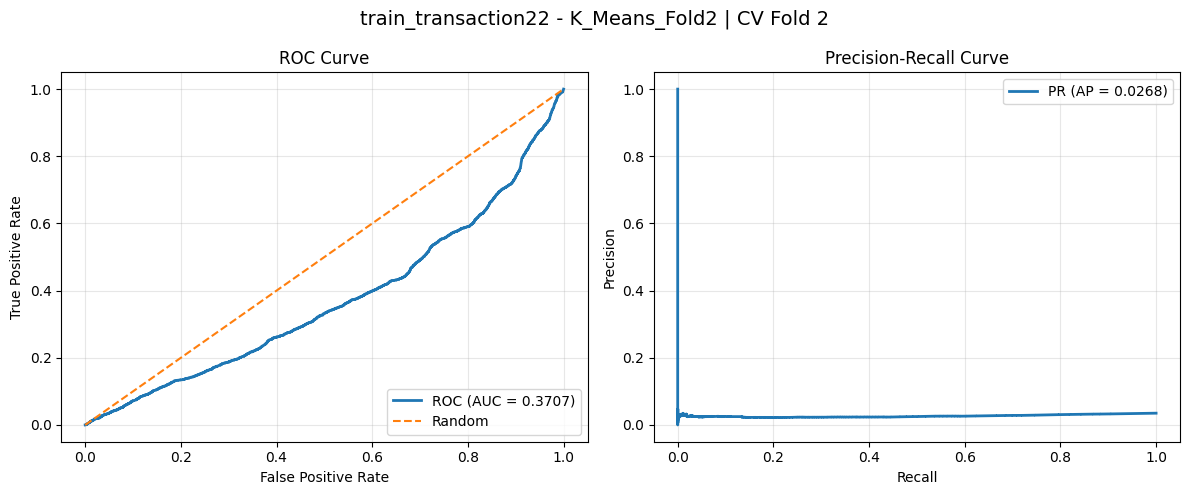

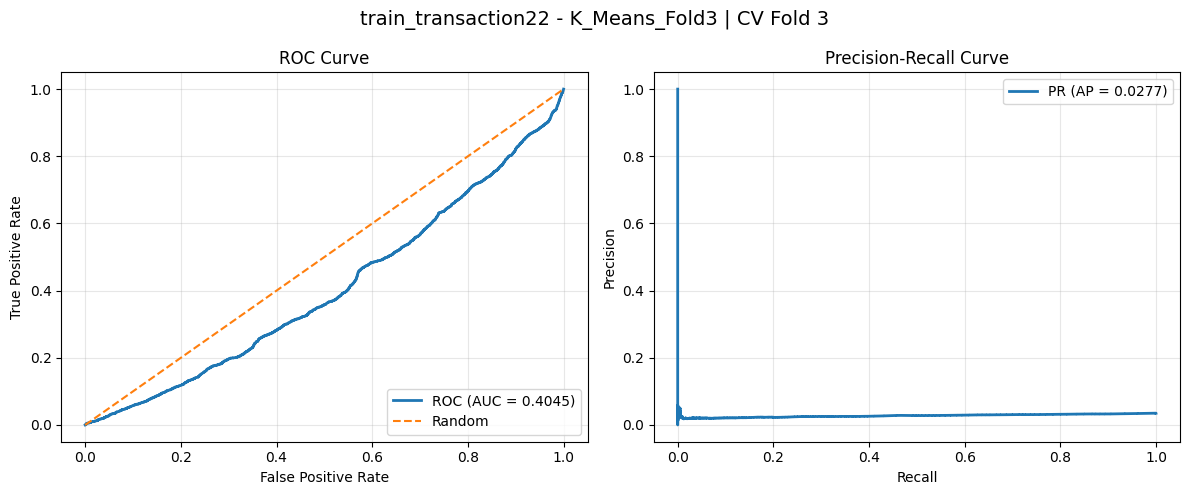

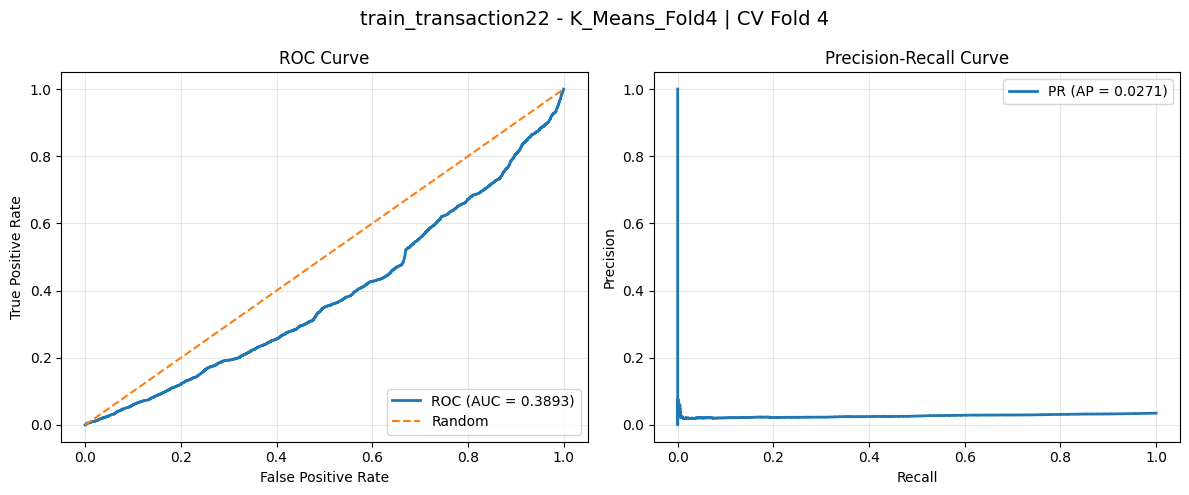

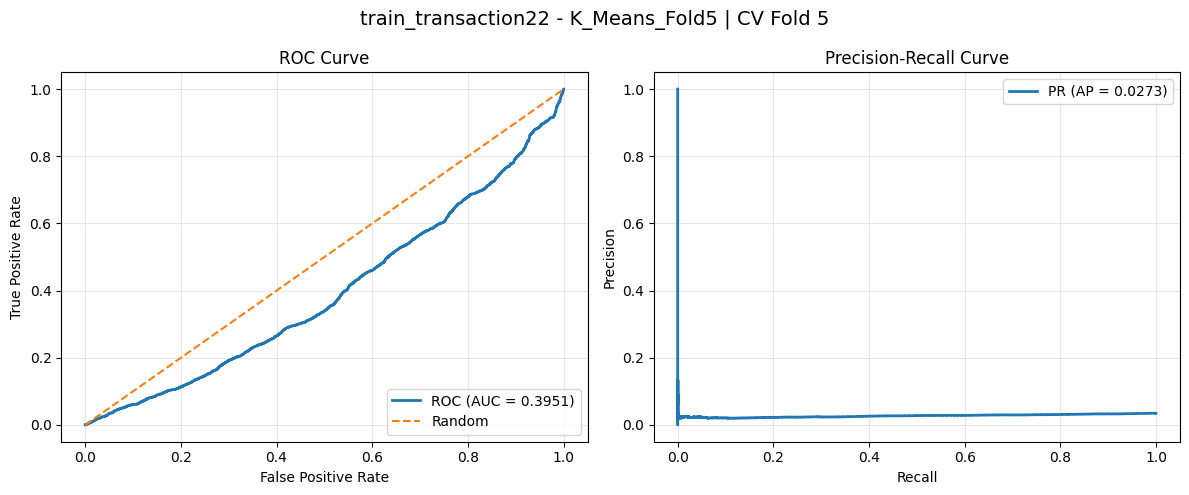

In [19]:
# ===================== Plot CV results =====================

for r in KM_results:
    plot_anomaly_roc_pr(y_test, r["test_scores"], DATASET_NAME, f"{MODEL_NAME}_Fold{r['fold']}", r["fold"])


In [23]:
if os.path.exists(DE_LONG_RESULTS):
    results = joblib.load(DE_LONG_RESULTS)
else:
    results = {}

results[MODEL_NAME] = {
    "test_scores": -KM_test_scores,
    "auc": roc_auc_score(y_test, -KM_test_scores)
}

joblib.dump(results, DE_LONG_RESULTS)

['IEEE_CIS_all_results.pkl']

In [20]:
if os.path.exists(METRICS):
    results = joblib.load(METRICS)
else:
    results = {}

results[MODEL_NAME] = {
    "metrics": KM_metrics,
    "cv_metrics": KM_cv_metrics
}

joblib.dump(results, METRICS)

['IEEE_CIS_metrics.pkl']